<a href="https://colab.research.google.com/github/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/blob/main/Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AIM

To implement a Random Forest classifier to predict Chronic Kidney Disease (CKD) and evaluate its performance.

THEORY

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

Key points:

Uses bagging (bootstrap sampling)
Combines multiple trees → better generalization
More robust than a single Decision Tree

Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Step 2 — Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/main/data/chronic_kidney_disease_full.csv"

df = pd.read_csv(url)

df.head()

,'age','bp','sg','al','su','rbc','pc','pcc','ba','bgr',...,'pcv','wbcc','rbcc','htn','dm','cad','appet','pe','ane','class'
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


Step 3 — Clean Column Names

In [3]:
df.columns = df.columns.str.strip().str.replace("'", "")

Step 4 — Handle Missing Values

In [5]:
num_cols = df.select_dtypes(include=['float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Step 5 — Encode Categorical Data

In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,32,72,34,1,4,1,0,1,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,26,56,34,0,3,1,0,1,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,19,70,34,0,4,1,2,1,1,0
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,20,62,19,1,3,1,2,2,1,0
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,23,68,27,0,3,1,0,1,0,0


Step 6 — Fix Target Variable

In [7]:
# Fix class values properly
df['class'] = df['class'].replace({2:1})

print(df['class'].value_counts())

class
0    250
1    150
Name: count, dtype: int64


Step 7 — Define Features and Target

In [8]:
X = df.drop('class', axis=1)
y = df['class']

Step 8 — Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

Step 9 — Train Random Forest Model

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Step 10 — Predictions

In [11]:
y_pred = rf_model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 0, 0, 0, 1, 0, 1, 0])

Step 11 — Evaluation

Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[76  0]
 [ 0 44]]


Classification Report

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00        44

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



Accuracy

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Note: Perfect accuracy may indicate strong feature separability in the dataset.

Step 12 — Feature Importance

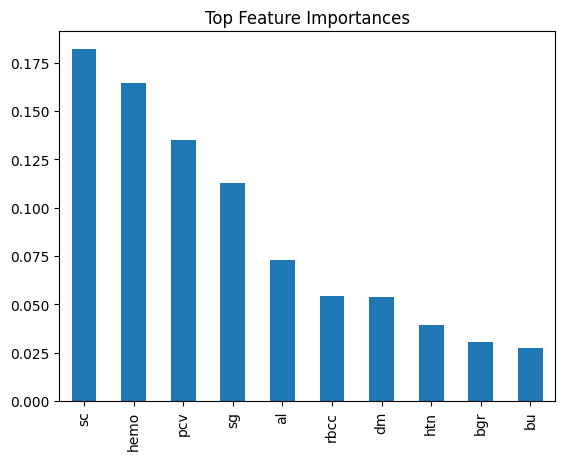

In [15]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

Step 13 — Confusion Matrix Visualization

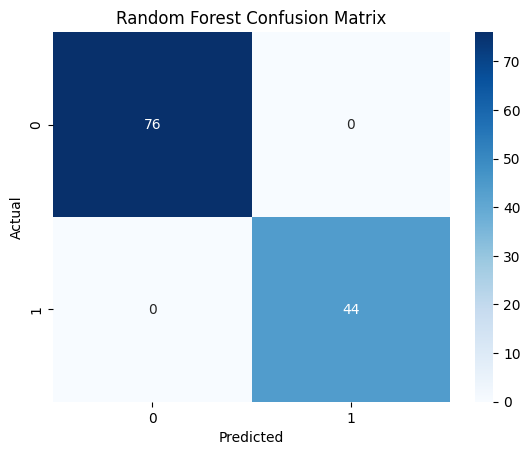

In [16]:
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Cross-Validation

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.9875 1.     0.9625 0.9875 1.    ]
Mean CV Accuracy: 0.9875


Train Accuracy vs Test Accuracy

In [18]:
train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


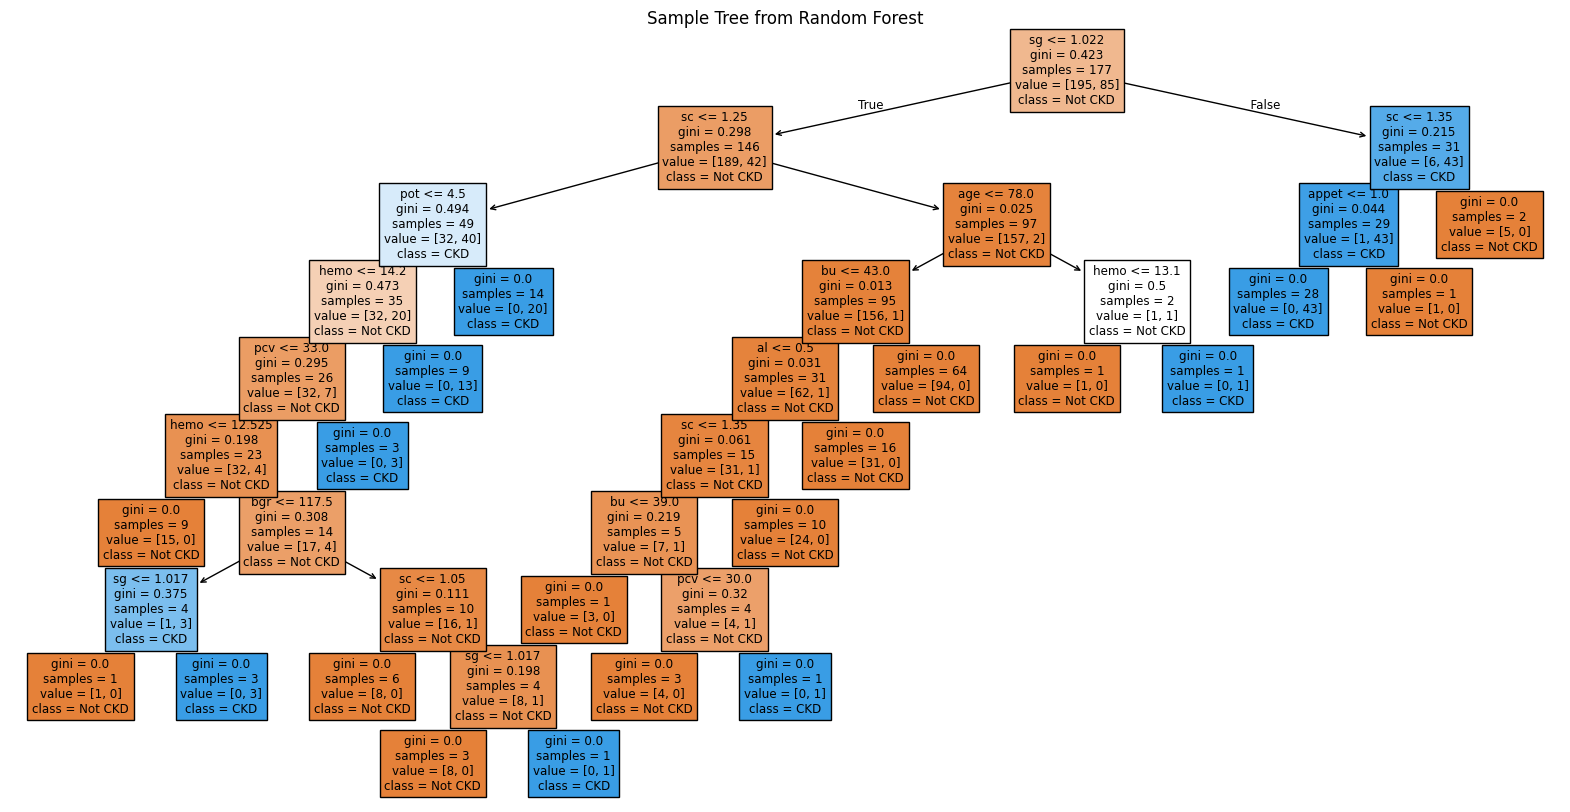

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    class_names=['Not CKD','CKD'],
    filled=True
)
plt.title("Sample Tree from Random Forest")
plt.show()

Conclusion

In this experiment, a Random Forest classifier was implemented on the Chronic Kidney Disease (CKD) dataset after performing data preprocessing, handling missing values, and encoding categorical variables. The dataset was split into training and testing sets, and the model was trained using multiple decision trees.

The model achieved very high accuracy on the test data, indicating strong predictive performance. Additional evaluation using confusion matrix and classification metrics confirmed that the model correctly classified CKD and non-CKD cases.

Random Forest proved to be more robust and accurate than a single Decision Tree due to its ensemble nature, which reduces overfitting and improves generalization. Feature importance analysis also helped in identifying the most influential factors in predicting CKD.

Thus, Random Forest is an effective and reliable algorithm for medical classification problems such as CKD prediction.